<a href="https://colab.research.google.com/github/cankurt-netizen/DSA210-PROJECT/blob/main/H2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H2 - Saudi Arabia Weather and Date Production Analysis

## Objective

- The objective of this notebook is to analyze whether weather conditions in Saudi Arabia have an affect on date production levels over time.

## Hypothesis

- H₀: Weather variables such as temperature and precipitation do not significantly affect Saudi Arabia’s date production.

- H₁: Weather variables such as temperature and precipitation significantly affect Saudi Arabia’s date production.

## 1) Uploading Production Dataset

- Upload and load the Saudi Arabia date production dataset from FAOSTAT for further analysis.

In [3]:
# Import libraries
import pandas as pd

# Upload production dataset
from google.colab import files
uploaded = files.upload()

# Load production dataset
df_prod = pd.read_csv("production (2).csv")

# Keep only production rows
df_prod = df_prod[df_prod["Element"] == "Production"]

# Keep only required columns
df_prod = df_prod[["Year", "Value"]]

# Rename columns for easier analysis
df_prod.columns = ["year", "production"]

Saving production (2).csv to production (2) (2).csv


## 2) Uploading Weather Dataset

- Upload and load the historical weather dataset containing temperature and precipitation variables.

In [4]:
# Upload weather dataset
from google.colab import files
uploaded = files.upload()

# Read weather dataset
df_weather = pd.read_csv("weather.csv", skiprows=1)

Saving weather.csv to weather.csv


## 3) Weather Data Cleaning and Preparation

- Clean the weather dataset, extract temperature and precipitation variables, and prepare yearly seasonal averages.

In [5]:
# Load weather dataset and skip metadata rows
df_weather = pd.read_csv("weather.csv", skiprows=2)

# Find the correct weather columns automatically
date_col = [c for c in df_weather.columns if "time" in c.lower()][0]
max_col = [c for c in df_weather.columns if "temperature_2m_max" in c.lower()][0]
min_col = [c for c in df_weather.columns if "temperature_2m_min" in c.lower()][0]
rain_col = [c for c in df_weather.columns if "precipitation_sum" in c.lower()][0]

# Keep only the needed weather columns
df_weather = df_weather[[date_col, max_col, min_col, rain_col]]

# Rename columns for easier use
df_weather.columns = ["date", "temp_max", "temp_min", "precipitation"]

# Convert date column and extract year and month
df_weather["date"] = pd.to_datetime(df_weather["date"])
df_weather["year"] = df_weather["date"].dt.year
df_weather["month"] = df_weather["date"].dt.month

# Create a function to classify each month into a season
def get_season(month):
    if month in [9, 10, 11]:
        return "fall"
    elif month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    else:
        return "summer"

# Apply the season function to each row
df_weather["season"] = df_weather["month"].apply(get_season)

# Assign December to the following winter year
df_weather["season_year"] = df_weather.apply(
    lambda row: row["year"] + 1 if row["month"] == 12 else row["year"],
    axis=1
)

# Calculate average daily temperature
df_weather["temp_avg"] = (
    df_weather["temp_max"] + df_weather["temp_min"]
) / 2

# Group weather data by year and season
df_seasonal = df_weather.groupby(["season_year", "season"]).agg({
    "temp_avg": "mean",
    "precipitation": "sum"
}).reset_index()

# Rename season_year to year for merging later
df_seasonal.rename(columns={"season_year": "year"}, inplace=True)

# Convert seasonal rows into separate seasonal columns
df_weather_final = df_seasonal.pivot(index="year", columns="season")

# Clean multi-level column names
df_weather_final.columns = ["_".join(col) for col in df_weather_final.columns]

# Reset index and preview final weather dataset
df_weather_final = df_weather_final.reset_index()
df_weather_final.head()

,year,temp_avg_fall,temp_avg_spring,temp_avg_summer,temp_avg_winter,precipitation_fall,precipitation_spring,precipitation_summer,precipitation_winter
0,2000,24.389011,25.271739,33.198913,14.335833,63.9,2.7,0.0,3.5
1,2001,25.279121,25.132065,32.791304,13.405000,0.0,43.5,0.0,8.2
2,2002,25.357143,24.525543,32.938043,15.343333,3.4,58.0,0.0,26.4
3,2003,24.955495,25.354891,33.254348,14.756111,6.0,9.9,0.0,32.2
4,2004,25.271429,24.821196,33.028261,15.221429,3.9,48.2,0.0,83.9


## 4) Merging Weather and Production Data

- This part combines the production and weather datasets, then creates new weather variables for growing and harvest seasons.

In [6]:
# Merge production data with seasonal weather data by year
df_final = pd.merge(df_prod, df_weather_final, on="year")
df_final.columns

# Create a time trend variable
df_final["year_trend"] = df_final["year"]

# Create lagged summer weather variables from the previous year
df_final["temp_summer_lag"] = df_final["temp_avg_summer"].shift(1)
df_final["rain_summer_lag"] = df_final["precipitation_summer"].shift(1)

# Drop rows with missing values caused by lagged variables
df_final = df_final.dropna()

# Create growing season temperature variable
df_final["temp_growing"] = (
    df_final["temp_avg_spring"] + df_final["temp_avg_summer"]
) / 2

# Create harvest season temperature variable
df_final["temp_harvest"] = df_final["temp_avg_fall"]

# Create growing season rainfall variable
df_final["rain_growing"] = (
    df_final["precipitation_spring"] + df_final["precipitation_summer"]
)

# Create harvest season rainfall variable
df_final["rain_harvest"] = df_final["precipitation_fall"]
df_final

,year,production,temp_avg_fall,temp_avg_spring,temp_avg_summer,temp_avg_winter,precipitation_fall,precipitation_spring,precipitation_summer,precipitation_winter,year_trend,temp_summer_lag,rain_summer_lag,temp_growing,temp_harvest,rain_growing,rain_harvest
1,2001,817887.00,25.279121,25.132065,32.791304,13.405000,0.0,43.5,0.0,8.2,2001,33.198913,0.0,28.961685,25.279121,43.5,0.0
2,2002,829540.00,25.357143,24.525543,32.938043,15.343333,3.4,58.0,0.0,26.4,2002,32.791304,0.0,28.731793,25.357143,58.0,3.4
3,2003,884088.00,24.955495,25.354891,33.254348,14.756111,6.0,9.9,0.0,32.2,2003,32.938043,0.0,29.304620,24.955495,9.9,6.0
4,2004,941293.00,25.271429,24.821196,33.028261,15.221429,3.9,48.2,0.0,83.9,2004,33.254348,0.0,28.924728,25.271429,48.2,3.9
5,2005,970488.00,25.319780,24.875543,32.929348,13.470556,3.9,54.3,0.0,78.4,2005,33.028261,0.0,28.902446,25.319780,54.3,3.9
6,2006,977036.00,25.252747,24.897826,33.070652,15.596111,38.9,15.9,0.0,7.0,2006,32.929348,0.0,28.984239,25.252747,15.9,38.9
7,2007,982546.00,25.180220,25.413587,32.582065,12.355000,0.0,23.0,0.0,40.1,2007,33.070652,0.0,28.997826,25.180220,23.0,0.0
8,2008,986409.00,24.758791,25.850000,32.523370,13.584066,87.7,14.0,0.0,17.4,2008,32.582065,0.0,29.186685,24.758791,14.0,87.7
9,2009,991660.00,25.756044,25.317391,33.439674,14.256111,4.7,28.6,0.5,4.8,2009,32.523370,0.0,29.378533,25.756044,29.1,4.7
10,2010,991546.00,25.009341,26.119022,34.062500,15.877222,0.0,30.1,0.0,27.3,2010,33.439674,0.5,30.090761,25.009341,30.1,0.0


## 5) Linear Regression Model

- Apply an Ordinary Least Squares (OLS) regression model to examine the relationship between weather conditions and date production.

In [7]:
import statsmodels.api as sm
import numpy as np

# Apply log transformation to production
df_final["log_production"] = np.log(df_final["production"])

# Select explanatory variables
X = df_final[["temp_avg_summer", "precipitation_fall", "year_trend"]]

# Define target variable
y = df_final["log_production"]

# Add constant term
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_production   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     23.89
Date:                Sun, 17 May 2026   Prob (F-statistic):           8.10e-07
Time:                        18:54:25   Log-Likelihood:                 15.695
No. Observations:                  24   AIC:                            -23.39
Df Residuals:                      20   BIC:                            -18.68
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -28.8125     14

## Results

- The regression model tested whether summer temperature, fall precipitation, and yearly trend have an effect on Saudi Arabia’s date production.

- The model produced an R² value of 0.782, indicating that the selected variables explain a large portion of the variation in production.

- The p-value for year_trend (0.030) is below 0.05, showing a statistically significant positive relationship between year and production.

- The p-value for temp_avg_summer (0.055) is slightly above 0.05, suggesting a possible positive relationship, although it is not statistically significant at the 5% level.

- The p-value for precipitation_fall (0.856) is much greater than 0.05, indicating no significant relationship with production.

- Since at least one explanatory variable is statistically significant, we reject the null hypothesis (H₀).

- The results suggest that long-term yearly trend has a significant relationship with Saudi Arabia’s date production, while weather variables show weaker effects in this model.


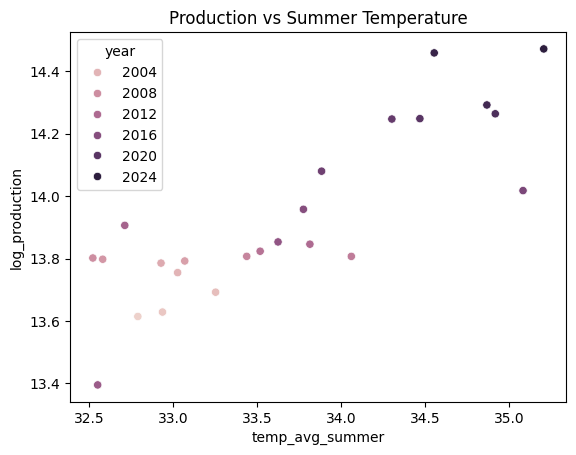

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plot between summer temperature and production
sns.scatterplot(x="temp_avg_summer", y="log_production", hue="year", data=df_final)

# Add title to the graph
plt.title("Production vs Summer Temperature")

# Display graph
plt.show()

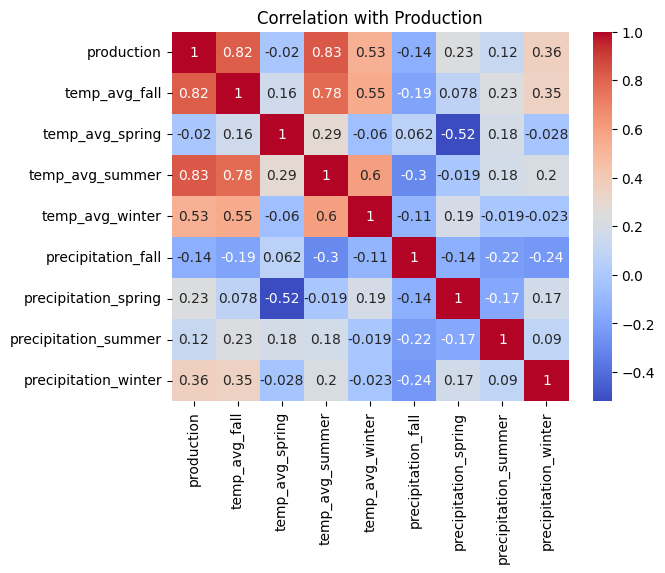

In [11]:
cols = [
    "production",
    "temp_avg_fall",
    "temp_avg_spring",
    "temp_avg_summer",
    "temp_avg_winter",
    "precipitation_fall",
    "precipitation_spring",
    "precipitation_summer",
    "precipitation_winter"
]

# Create correlation heatmap between production and weather variables
sns.heatmap(df_final[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation with Production")
plt.show()